In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft2, fftshift, ifftshift, ifft2

Image shape: (330, 330)


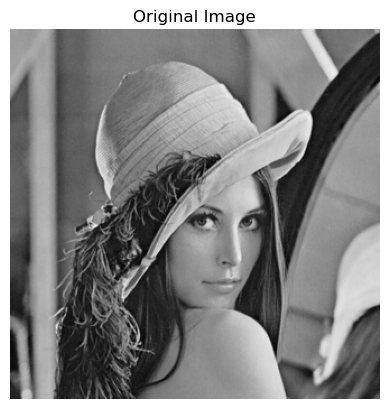

In [2]:
# Load the image in grayscale
img = cv2.imread(r"E:\SRM\Digital Image\Lab 6 - 14th October\test_image.png", 0)

# Check the image dimensions
print(f"Image shape: {img.shape}")
# Prints the shape (dimensions) of the image. This tells you how many rows and columns of pixels the image has.

# Display the original image
plt.imshow(img, cmap='gray') # Displays the image in grayscale
plt.title("Original Image")  # Adds title to the image
plt.axis('off')              # Hides the axis around the image for a cleaner display.
plt.show()                   # Actually renders and displays the image.


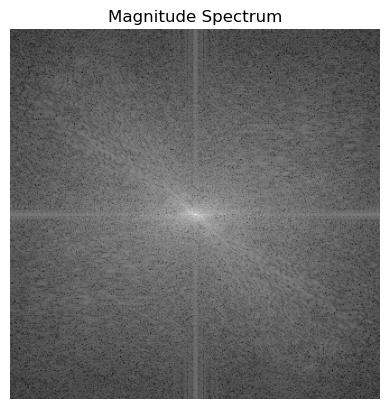

In [3]:
# Perform Fourier Transform
f_transform = fft2(img)
# This computes the 2D Fast Fourier Transform of the image. The result, 
# f_transform, contains complex numbers representing the frequency domain of the image.


# Shift the zero frequency component to the center
f_transform_shifted = fftshift(f_transform)
# This shifts the zero-frequency component (which is typically at the corner) to the center of the image for better visualization. 
# The low-frequency components are now in the center, and high-frequency components are around the edges.


# Compute the magnitude spectrum (logarithmic scale for better visibility)
magnitude_spectrum = np.log(np.abs(f_transform_shifted) + 1)


# Display the magnitude spectrum
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title("Magnitude Spectrum")
plt.axis('off')
plt.show()


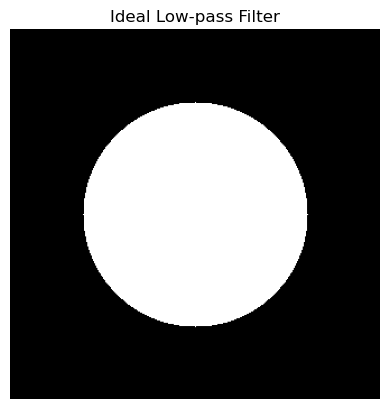

In [26]:
# Get the dimensions of the image
M, N = img.shape

# Initialize the filter with zeros
H = np.zeros((M, N), dtype=np.float32)

# Set the cutoff frequency
D0 = 100

# Design the filter: set values inside the cutoff frequency to 1, others remain 0
for u in range(M):
    for v in range(N):
        D = np.sqrt((u - M/2)**2 + (v - N/2)**2)
        if D <= D0:
            H[u, v] = 1
        else:
            H[u, v] = 0

# Display the ideal low-pass filter
plt.imshow(H, cmap='gray')
plt.title("Ideal Low-pass Filter")
plt.axis('off')
plt.show()


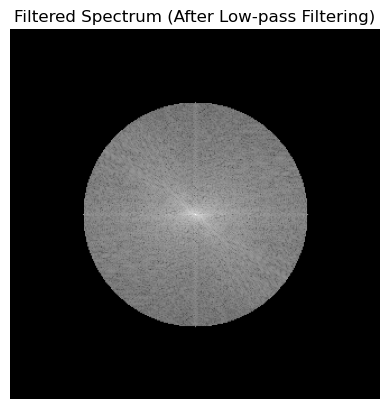

In [28]:
# Apply the filter to the shifted Fourier transform
Gshift = f_transform_shifted * H

# Display the magnitude spectrum of the filtered image
plt.imshow(np.log1p(np.abs(Gshift)), cmap='gray')
plt.title("Filtered Spectrum (After Low-pass Filtering)")
plt.axis('off')
plt.show()


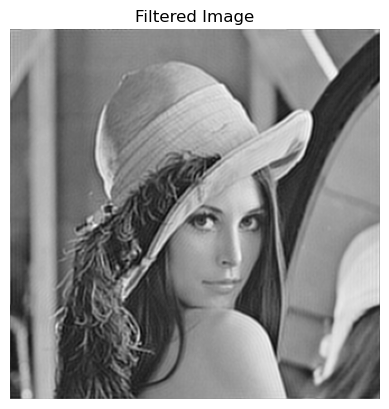

In [30]:
# Apply the inverse shift
G = ifftshift(Gshift)

# Perform the inverse Fourier transform
g = np.abs(ifft2(G))

# Display the filtered image
plt.imshow(g, cmap='gray')
plt.title("Filtered Image")
plt.axis('off')
plt.show()
